# FlightWise: Flight Delay Prediction System

## Business Problem

Flight delays cause:

- Passenger dissatisfaction
- Increased operational costs
- Crew scheduling issues
- Airport congestion

Goal:
Predict whether a flight will arrive 15+ minutes late.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Dataset Overview


In [2]:
df=pd.read_csv("data.csv")

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\1381553570.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data.csv")


In [3]:
df

,Year,Quarter,Month,DayofMonth,DayOfWeek,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,Originally_Scheduled_Code_Share_Airline,Operating_Airline,Origin,...,Dest,DestStateName,CRSDepTime,DepTimeBlk,CRSArrTime,ArrDel15,ArrTimeBlk,CRSElapsedTime,Distance,DistanceGroup
0,2024,1,1,14,7,UA,UA_CODESHARE,NaN,G7,MHT,...,EWR,New Jersey,1738,1700-1759,1922,1.0,1900-1959,104.0,209.0,1
1,2024,1,1,14,7,UA,UA_CODESHARE,NaN,G7,IAD,...,EWR,New Jersey,815,0800-0859,934,1.0,0900-0959,79.0,212.0,1
2,2024,1,1,14,7,UA,UA_CODESHARE,NaN,G7,EWR,...,MHT,New Hampshire,1540,1500-1559,1656,1.0,1600-1659,76.0,209.0,1
3,2024,1,1,14,7,UA,UA_CODESHARE,NaN,G7,STL,...,ORD,Illinois,630,0600-0659,758,1.0,0700-0759,88.0,258.0,2
4,2024,1,1,14,7,UA,UA_CODESHARE,NaN,G7,STL,...,IAD,Virginia,1300,1300-1359,1603,1.0,1600-1659,123.0,696.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
582420,2024,1,1,25,4,B6,B6,NaN,B6,LAS,...,LAX,California,1859,1800-1859,2010,0.0,2000-2059,71.0,236.0,1
582421,2024,1,1,25,4,B6,B6,NaN,B6,LAX,...,LAS,Nevada,1650,1600-1659,1803,1.0,1800-1859,73.0,236.0,1
582422,2024,1,1,25,4,B6,B6,NaN,B6,LAX,...,BOS,Massachusetts,1330,1300-1359,2201,0.0,2200-2259,331.0,2611.0,11
582423,2024,1,1,25,4,B6,B6,NaN,B6,SJU,...,EWR,New Jersey,715,0700-0759,1041,0.0,1000-1059,266.0,1608.0,7


In [4]:
print(df.shape)

(582425, 21)


In [5]:
df.isnull().sum().sort_values(ascending=False)

Originally_Scheduled_Code_Share_Airline    582371
ArrDel15                                    23710
Month                                           0
Quarter                                         0
Year                                            0
DayOfWeek                                       0
DayofMonth                                      0
Operated_or_Branded_Code_Share_Partners         0
Marketing_Airline_Network                       0
Origin                                          0
OriginStateName                                 0
Dest                                            0
Operating_Airline                               0
DestStateName                                   0
CRSDepTime                                      0
DepTimeBlk                                      0
CRSArrTime                                      0
ArrTimeBlk                                      0
CRSElapsedTime                                  0
Distance                                        0


## 3. Data Cleaning

In [6]:
df.drop(
    columns=['Originally_Scheduled_Code_Share_Airline'],
    inplace=True
)

In [7]:
df = df.dropna(subset=['ArrDel15'])

In [8]:
print(df.shape)
print(df['ArrDel15'].isnull().sum())

(558715, 20)
0


In [9]:
print(df['ArrDel15'].value_counts())

print("\nPercentage:")
print(df['ArrDel15'].value_counts(normalize=True) * 100)

ArrDel15
0.0    424140
1.0    134575
Name: count, dtype: int64

Percentage:
ArrDel15
0.0    75.91348
1.0    24.08652
Name: proportion, dtype: float64


In [10]:
origin_state = (
    df.groupby('Origin')['OriginStateName']
      .first()
      .to_dict()
)

dest_state = (
    df.groupby('Dest')['DestStateName']
      .first()
      .to_dict()
)

In [11]:
import joblib
joblib.dump(origin_state, "origin_state.pkl")
joblib.dump(dest_state, "dest_state.pkl")

['dest_state.pkl']

Executive Summary

In [12]:
import joblib

route_distance = (
    df.groupby(['Origin', 'Dest'])['Distance']
      .median()
      .to_dict()
)

joblib.dump(
    route_distance,
    "route_distance.pkl"
)

['route_distance.pkl']

In [13]:
route_duration = (
    df.groupby(['Origin', 'Dest'])['CRSElapsedTime']
      .median()
      .to_dict()
)

joblib.dump(
    route_duration,
    "route_duration.pkl"
)

['route_duration.pkl']

In [14]:
print(next(iter(route_distance.items())))

(('ABE', 'ATL'), 692.0)


In [15]:
import joblib

airline_routes = {}

for airline in df['Operating_Airline '].unique():

    airline_df = df[
        df['Operating_Airline '] == airline
    ]

    airline_routes[airline] = {}

    for origin in airline_df['Origin'].unique():

        destinations = sorted(
            airline_df[
                airline_df['Origin'] == origin
            ]['Dest'].unique()
        )

        airline_routes[airline][origin] = destinations

joblib.dump(
    airline_routes,
    "airline_routes.pkl"
)

['airline_routes.pkl']

## 4. Exploratory Data Analysis

In [16]:
print("Total Flights:", len(df))
print("Total Features:", df.shape[1])

delay_rate = df['ArrDel15'].mean()*100

print(f"Overall Delay Rate: {delay_rate:.2f}%")

Total Flights: 558715
Total Features: 20
Overall Delay Rate: 24.09%


Delay Distribution

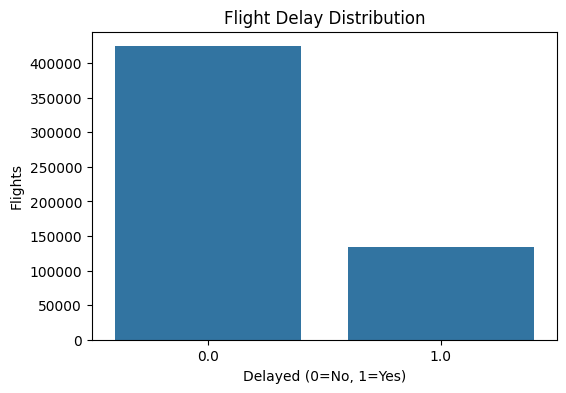

In [17]:
delay_counts = df['ArrDel15'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(
    x=delay_counts.index,
    y=delay_counts.values
)

plt.title("Flight Delay Distribution")
plt.xlabel("Delayed (0=No, 1=Yes)")
plt.ylabel("Flights")
plt.show()

Airline Performance Analysis

In [18]:
airline_volume = df['Operating_Airline '].value_counts()

print(airline_volume)
airline_summary = (
    df.groupby('Operating_Airline ')
      .agg(
          Flights=('ArrDel15','count'),
          DelayRate=('ArrDel15','mean')
      )
)

airline_summary['DelayRate'] *= 100

airline_summary.sort_values(
    'DelayRate',
    ascending=False
)

Operating_Airline 
WN    111613
AA     75889
DL     73722
OO     54206
UA     54003
YX     21848
NK     20081
MQ     19741
B6     19172
9E     16219
OH     15539
AS     14495
F9     14045
G4      8366
PT      8033
YV      6794
HA      6475
C5      5464
QX      5414
G7      3944
ZW      3652
Name: count, dtype: int64


,Flights,DelayRate
Operating_Airline,,
ZW,3652,46.714129
AA,75889,29.374481
B6,19172,29.026706
MQ,19741,27.729092
AS,14495,27.561228
F9,14045,27.155571
HA,6475,26.841699
NK,20081,26.263632
YV,6794,25.566676


Airport Risk Analysis

In [19]:
airport_summary = (
    df.groupby('Origin')
      .agg(
          Flights=('ArrDel15','count'),
          DelayRate=('ArrDel15','mean')
      )
)

airport_summary = airport_summary[
    airport_summary['Flights'] > 1000
]

airport_summary['DelayRate'] *= 100

Destination Airport Analysis

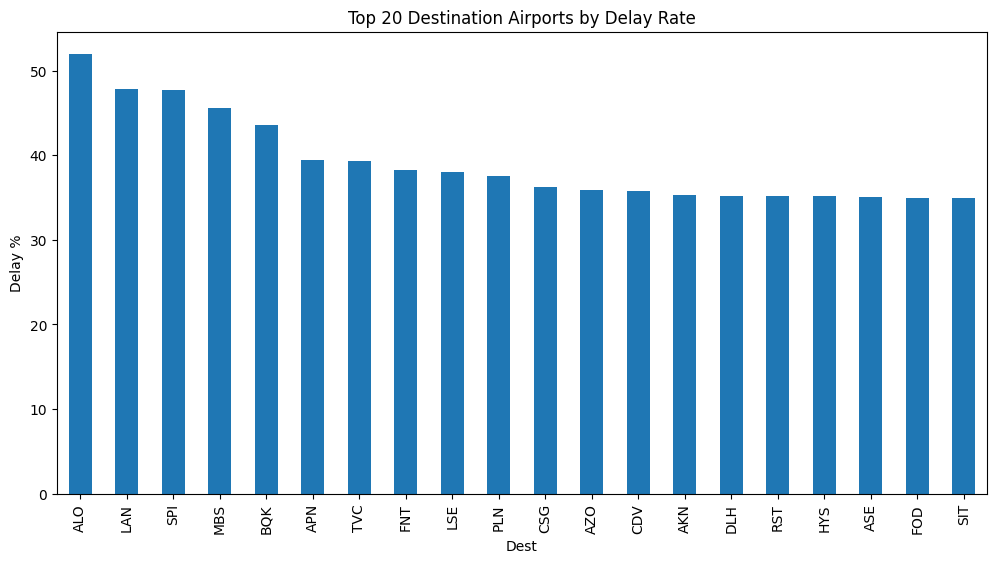

In [20]:
dest_delay = (
    df.groupby('Dest')['ArrDel15']
      .mean()
      .sort_values(ascending=False)
      .head(20)
      * 100
)

plt.figure(figsize=(12,6))

dest_delay.plot(kind='bar')

plt.title("Top 20 Destination Airports by Delay Rate")
plt.ylabel("Delay %")
plt.show()

Time-of-Day Analysis

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\2786621415.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DepartureHour'] = df['CRSDepTime']//100


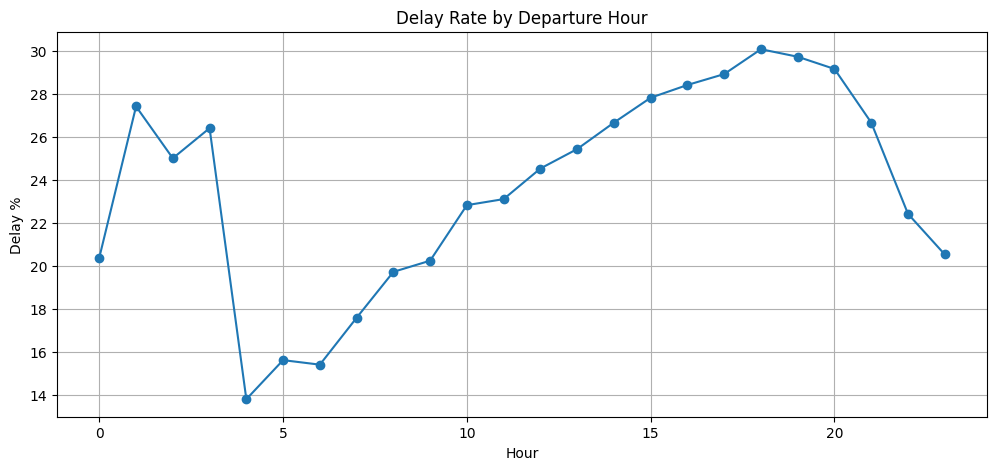

In [21]:
df['DepartureHour'] = df['CRSDepTime']//100

hourly_delay = (
    df.groupby('DepartureHour')['ArrDel15']
      .mean()
      * 100
)

plt.figure(figsize=(12,5))

hourly_delay.plot(marker='o')

plt.title("Delay Rate by Departure Hour")
plt.ylabel("Delay %")
plt.xlabel("Hour")
plt.grid()
plt.show()

Day-of-Week Analysis

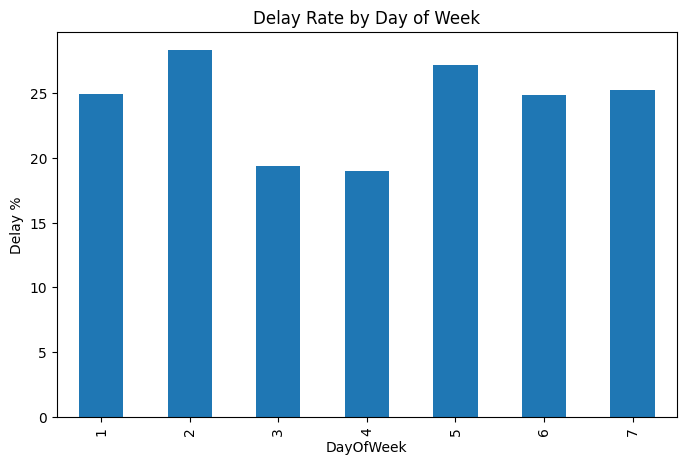

In [22]:
weekday_delay = (
    df.groupby('DayOfWeek')['ArrDel15']
      .mean()
      * 100
)

plt.figure(figsize=(8,5))

weekday_delay.plot(kind='bar')

plt.title("Delay Rate by Day of Week")
plt.ylabel("Delay %")
plt.show()

Flight Distance Analysis

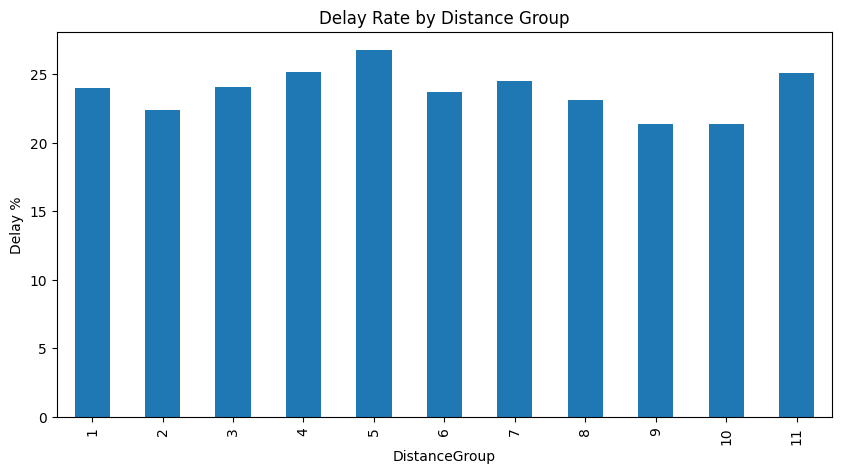

In [23]:
distance_delay = (
    df.groupby('DistanceGroup')['ArrDel15']
      .mean()
      * 100
)

plt.figure(figsize=(10,5))

distance_delay.plot(kind='bar')

plt.title("Delay Rate by Distance Group")
plt.ylabel("Delay %")
plt.show()

State-Level Analysis

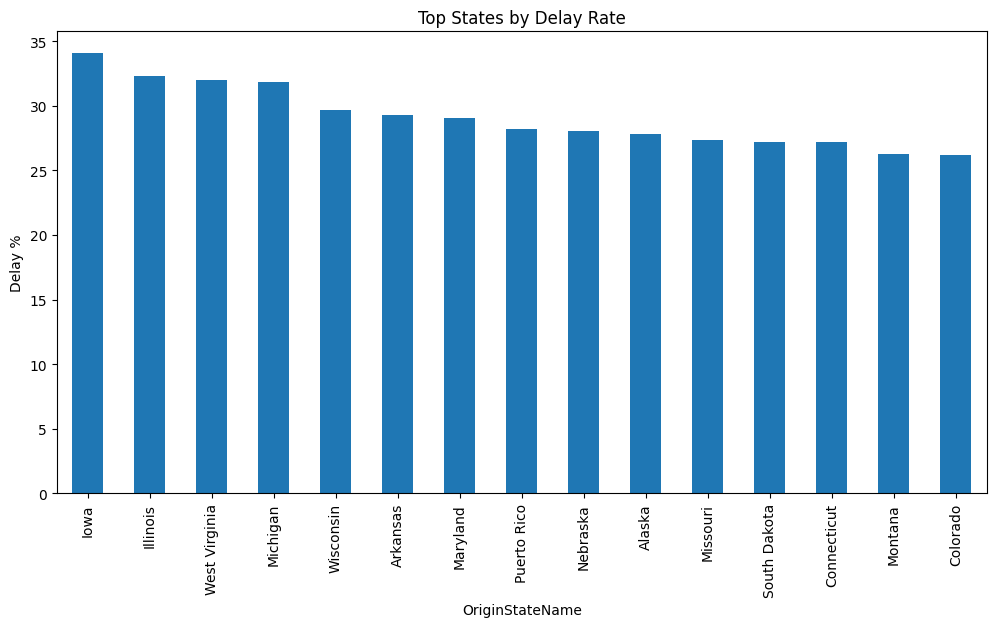

In [24]:
state_delay = (
    df.groupby('OriginStateName')['ArrDel15']
      .mean()
      .sort_values(ascending=False)
      .head(15)
      * 100
)

plt.figure(figsize=(12,6))

state_delay.plot(kind='bar')

plt.title("Top States by Delay Rate")
plt.ylabel("Delay %")
plt.show()

Route Analysis

In [25]:
df['Route'] = df['Origin'] + "_" + df['Dest']

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\4218531418.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Route'] = df['Origin'] + "_" + df['Dest']


In [26]:
route_summary = (
    df.groupby('Route')
      .agg(
          Flights=('ArrDel15','count'),
          DelayRate=('ArrDel15','mean')
      )
)

route_summary = route_summary[
    route_summary['Flights'] >= 100
]

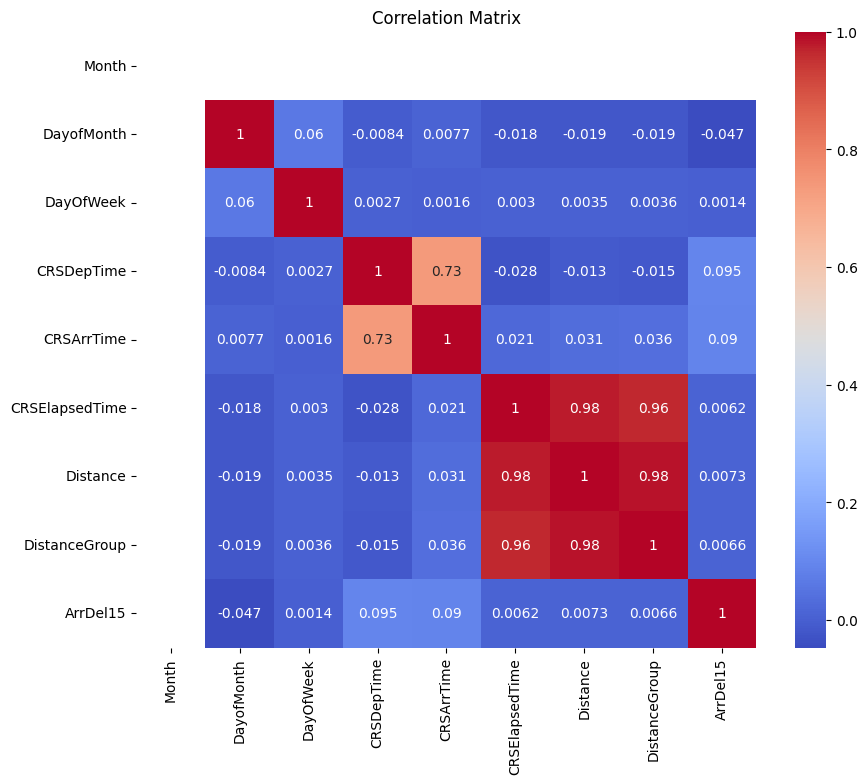

In [27]:
num_cols = [
    'Month',
    'DayofMonth',
    'DayOfWeek',
    'CRSDepTime',
    'CRSArrTime',
    'CRSElapsedTime',
    'Distance',
    'DistanceGroup',
    'ArrDel15'
]

corr = df[num_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

In [28]:
df.drop(
    columns=[
        'Year',
        'Quarter',
        'Month'
    ],
    inplace=True
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\4231661120.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(


| Attribute | Value |
|------------|--------|
| Flights | 558,715 |
| Time Period | January 2024 |
| Target | ArrDel15 |
| Positive Class | Delayed |
| Negative Class | On-Time |

## 5. Feature Engineering

In [29]:
df["DepartureHour"]=df["CRSDepTime"] // 100

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\3791076774.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["DepartureHour"]=df["CRSDepTime"] // 100


In [30]:
df['ArrivalHour'] = df['CRSArrTime'] // 100

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\1751852040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ArrivalHour'] = df['CRSArrTime'] // 100


In [31]:
df['IsWeekend'] = (
    df['DayOfWeek']
      .isin([6,7])
      .astype(int)
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\996693487.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IsWeekend'] = (


In [32]:
df['Route'] = (
    df['Origin']
    + "_"
    + df['Dest']
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\2127588577.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Route'] = (


In [33]:
origin_counts = (
    df['Origin']
      .value_counts()
)

dest_counts = (
    df['Dest']
      .value_counts()
)

df['OriginTraffic'] = (
    df['Origin']
      .map(origin_counts)
)

df['DestTraffic'] = (
    df['Dest']
      .map(dest_counts)
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\3613889944.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OriginTraffic'] = (
C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\3613889944.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DestTraffic'] = (


In [34]:
df['FlightDurationCategory'] = pd.cut(
    df['CRSElapsedTime'],
    bins=[0,120,240,360,10000],
    labels=[
        'Short',
        'Medium',
        'Long',
        'VeryLong'
    ]
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\367408036.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FlightDurationCategory'] = pd.cut(


In [35]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 558715 entries, 0 to 582424
Data columns (total 24 columns):
 #   Column                                   Non-Null Count   Dtype   
---  ------                                   --------------   -----   
 0   DayofMonth                               558715 non-null  int64   
 1   DayOfWeek                                558715 non-null  int64   
 2   Marketing_Airline_Network                558715 non-null  object  
 3   Operated_or_Branded_Code_Share_Partners  558715 non-null  object  
 4   Operating_Airline                        558715 non-null  object  
 5   Origin                                   558715 non-null  object  
 6   OriginStateName                          558715 non-null  object  
 7   Dest                                     558715 non-null  object  
 8   DestStateName                            558715 non-null  object  
 9   CRSDepTime                               558715 non-null  int64   
 10  DepTimeBlk               

## 6. Data Preprocessing

In [36]:
cardinality = df.select_dtypes(
    include=['object','category']
).nunique().sort_values(ascending=False)

print(cardinality)

Route                                      5876
Origin                                      351
Dest                                        351
DestStateName                                52
OriginStateName                              52
Operating_Airline                            21
DepTimeBlk                                   19
ArrTimeBlk                                   19
Operated_or_Branded_Code_Share_Partners      14
Marketing_Airline_Network                    10
FlightDurationCategory                        4
dtype: int64


In [37]:
df.drop(
    columns=['CRSDepTime', 'CRSArrTime'],
    inplace=True
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\2806175340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(


In [38]:
df.to_csv(
    "flight_delay_feature_engineered.csv",
    index=False
)

<Axes: >

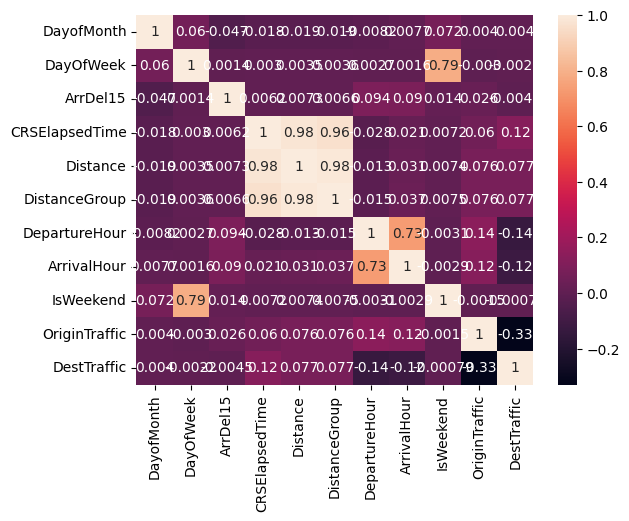

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [40]:
origin_traffic = df['Origin'].value_counts().to_dict()

dest_traffic = df['Dest'].value_counts().to_dict()

origin_freq = (
    df['Origin']
    .value_counts(normalize=True)
    .to_dict()
)

dest_freq = (
    df['Dest']
    .value_counts(normalize=True)
    .to_dict()
)

route_freq = (
    df['Route']
    .value_counts(normalize=True)
    .to_dict()
)

In [41]:
import joblib

joblib.dump(
    origin_traffic,
    'origin_traffic.pkl'
)

joblib.dump(
    dest_traffic,
    'dest_traffic.pkl'
)

joblib.dump(
    origin_freq,
    'origin_freq.pkl'
)

joblib.dump(
    dest_freq,
    'dest_freq.pkl'
)

joblib.dump(
    route_freq,
    'route_freq.pkl'
)

['route_freq.pkl']

In [42]:
airlines = sorted(
    df['Operating_Airline '].unique()
)

origins = sorted(
    df['Origin'].unique()
)

destinations = sorted(
    df['Dest'].unique()
)

In [43]:
joblib.dump(
    airlines,
    'airlines.pkl'
)

joblib.dump(
    origins,
    'origins.pkl'
)

joblib.dump(
    destinations,
    'destinations.pkl'
)

['destinations.pkl']

Encoding

In [44]:
for col in ['Origin', 'Dest', 'Route']:
    freq = df[col].value_counts(normalize=True)
    df[col + '_Freq'] = df[col].map(freq)

df.drop(
    columns=['Origin', 'Dest', 'Route'],
    inplace=True
)

C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\4240990685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_Freq'] = df[col].map(freq)
C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\4240990685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_Freq'] = df[col].map(freq)
C:\Users\Kunal jhindal\AppData\Local\Temp\ipykernel_9180\4240990685.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [45]:
cat_cols = [
    'Marketing_Airline_Network',
    'Operated_or_Branded_Code_Share_Partners',
    'Operating_Airline ',
    'OriginStateName',
    'DestStateName',
    'DepTimeBlk',
    'ArrTimeBlk',
    'FlightDurationCategory'
]

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

In [46]:
df_lr = df.drop(
    columns=[
        'DistanceGroup',
        'CRSElapsedTime'
    ]
)

In [47]:
X = df_lr.drop('ArrDel15', axis=1)
y = df_lr['ArrDel15']

## 7. Model Building

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=42,stratify=y)

In [49]:
print(X_test.shape)

(111743, 194)


In [50]:
print(X_train.shape)

(446972, 194)


### Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=200,
    class_weight='balanced'
)
lr.fit(X_train, y_train)

c:\Users\Kunal jhindal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=200)

In [52]:
y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [53]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.557466686951308
Precision: 0.2922620254798208
Recall   : 0.5889652610068735
F1 Score : 0.3906646622470858
ROC AUC  : 0.5941357192100607

Classification Report
              precision    recall  f1-score   support

         0.0       0.81      0.55      0.65     84828
         1.0       0.29      0.59      0.39     26915

    accuracy                           0.56    111743
   macro avg       0.55      0.57      0.52    111743
weighted avg       0.68      0.56      0.59    111743



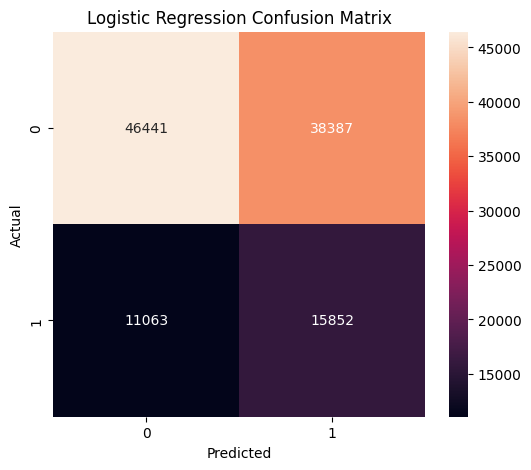

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

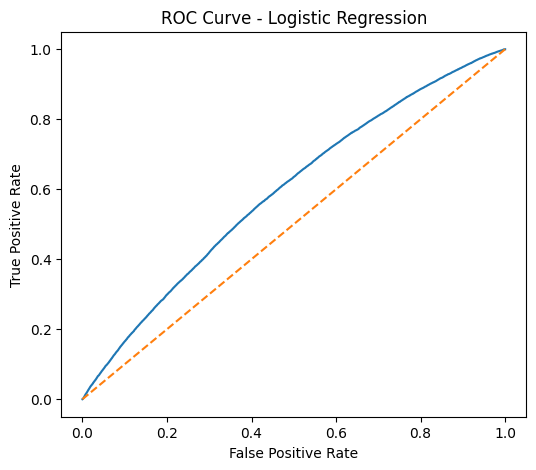

In [55]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.show()

In [56]:
results = []

results.append({
    'Model':'Logistic Regression',
    'Accuracy':accuracy_score(y_test,y_pred_lr),
    'Precision':precision_score(y_test,y_pred_lr),
    'Recall':recall_score(y_test,y_pred_lr),
    'F1':f1_score(y_test,y_pred_lr),
    'ROC_AUC':roc_auc_score(y_test,y_prob_lr)
})

### Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [58]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print(classification_report(y_test, y_pred_rf))

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

         0.0       0.76      1.00      0.86     84828
         1.0       0.71      0.03      0.07     26915

    accuracy                           0.76    111743
   macro avg       0.74      0.52      0.47    111743
weighted avg       0.75      0.76      0.67    111743

Accuracy : 0.7640478598211968
Precision: 0.7074829931972789
Recall   : 0.03477614712985324
F1 Score : 0.06629364685884269
ROC AUC  : 0.7341359575654225


In [60]:
results.append({
    'Model':'Random Forest',
    'Accuracy':accuracy_score(y_test,y_pred_rf),
    'Precision':precision_score(y_test,y_pred_rf),
    'Recall':recall_score(y_test,y_pred_rf),
    'F1':f1_score(y_test,y_pred_rf),
    'ROC_AUC':roc_auc_score(y_test,y_prob_rf)
})

### XGBoost

In [61]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print(classification_report(y_test, y_pred_xgb))

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

         0.0       0.81      0.96      0.88     84828
         1.0       0.71      0.30      0.42     26915

    accuracy                           0.80    111743
   macro avg       0.76      0.63      0.65    111743
weighted avg       0.79      0.80      0.77    111743

Accuracy : 0.8011419059806878
Precision: 0.7077726628895185
Recall   : 0.2970462567341631
F1 Score : 0.41846588678652746
ROC AUC  : 0.7804542692725838


In [64]:
results.append({
    'Model':'XGBoost',
    'Accuracy':accuracy_score(y_test, y_pred_xgb),
    'Precision':precision_score(y_test, y_pred_xgb),
    'Recall':recall_score(y_test, y_pred_xgb),
    'F1':f1_score(y_test, y_pred_xgb),
    'ROC_AUC':roc_auc_score(y_test, y_prob_xgb)
})

## 8. Model Evaluation

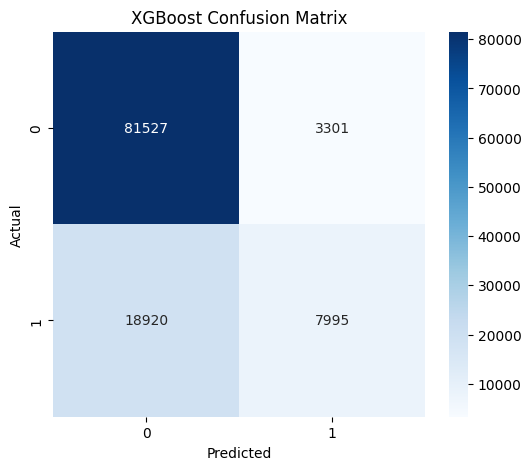

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

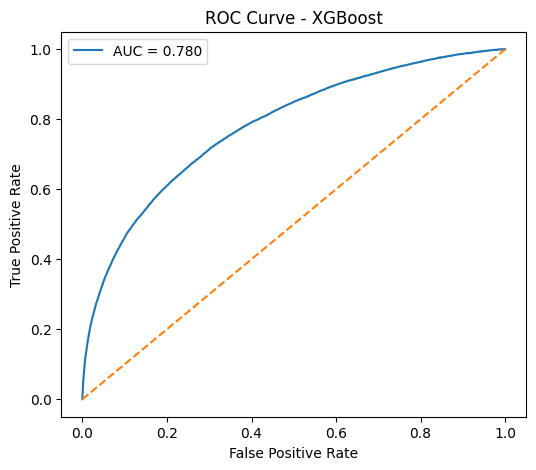

In [66]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob_xgb):.3f}")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()

plt.show()

In [67]:
y_pred_xgb_35 = (y_prob_xgb >= 0.35).astype(int)

print(classification_report(
    y_test,
    y_pred_xgb_35
))

              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86     84828
         1.0       0.56      0.50      0.53     26915

    accuracy                           0.79    111743
   macro avg       0.71      0.69      0.70    111743
weighted avg       0.78      0.79      0.78    111743



## 9. Feature Importance Analysis

In [68]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance.head(20))

                                        Feature  Importance
49                        Operating_Airline _WN    0.028709
56                   OriginStateName_California    0.023791
63                     OriginStateName_Illinois    0.022392
52                        Operating_Airline _ZW    0.021365
112                        DestStateName_Hawaii    0.018875
72                     OriginStateName_Michigan    0.018469
145                         DestStateName_Texas    0.015028
51                        Operating_Airline _YX    0.014687
61                       OriginStateName_Hawaii    0.014647
35                        Operating_Airline _B6    0.014426
94                        OriginStateName_Texas    0.012820
53                       OriginStateName_Alaska    0.012620
24   Operated_or_Branded_Code_Share_Partners_DL    0.012057
0                                    DayofMonth    0.011828
11                 Marketing_Airline_Network_AS    0.011238
54                      OriginStateName_

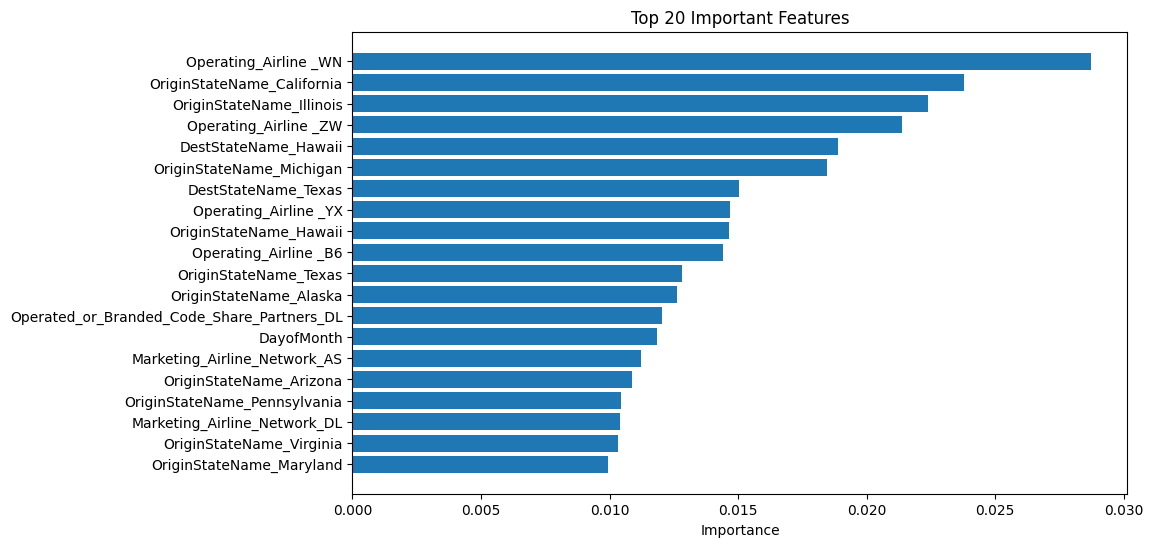

In [69]:
top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")
plt.xlabel("Importance")

plt.show()

### Interpretation

The most influential predictors include:

- Airline information
- Origin and destination states
- Departure time
- Route characteristics

This indicates that operational and geographical factors are major contributors to flight delays.

## Business Insights

1. Airline-specific operational patterns significantly influence delays.

2. Certain origin and destination states consistently show higher delay risk.

3. Flights departing later in the day are more prone to delays.

4. Route and airport congestion indicators contribute to delay prediction.

5. XGBoost captures nonlinear relationships better than Logistic Regression and Random Forest.

In [70]:
import joblib

joblib.dump(
    xgb,
    "flight_delay_model.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "model_columns.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [71]:
loaded_model = joblib.load(
    "flight_delay_model.pkl"
)

sample_pred = loaded_model.predict(
    X_test.head(5)
)

print(sample_pred)

[0 0 0 0 0]


In [72]:
metrics = {
    "Accuracy": 0.80,
    "Precision": 0.56,
    "Recall": 0.50,
    "F1": 0.53,
    "ROC_AUC": 0.78
}

In [73]:
joblib.dump(metrics, "metrics.pkl")

['metrics.pkl']

In [74]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.557467,0.292262,0.588965,0.390665,0.594136
1,Random Forest,0.764048,0.707483,0.034776,0.066294,0.734136
2,XGBoost,0.801142,0.707773,0.297046,0.418466,0.780454


In [75]:
best_model = results_df.loc[
    results_df['ROC_AUC'].idxmax()
]

print(best_model)

Model         XGBoost
Accuracy     0.801142
Precision    0.707773
Recall       0.297046
F1           0.418466
ROC_AUC      0.780454
Name: 2, dtype: object


In [76]:
results_df = results_df.round(3)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.557,0.292,0.589,0.391,0.594
1,Random Forest,0.764,0.707,0.035,0.066,0.734
2,XGBoost,0.801,0.708,0.297,0.418,0.780


In [77]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

### Why XGBoost?

Although accuracy differences were small,
XGBoost achieved the best ROC-AUC score
and offered the strongest balance between
precision and recall.

Logistic Regression:
High recall but many false positives.

Random Forest:
High precision but poor recall.

XGBoost:
Best balance between delayed and non-delayed flights.

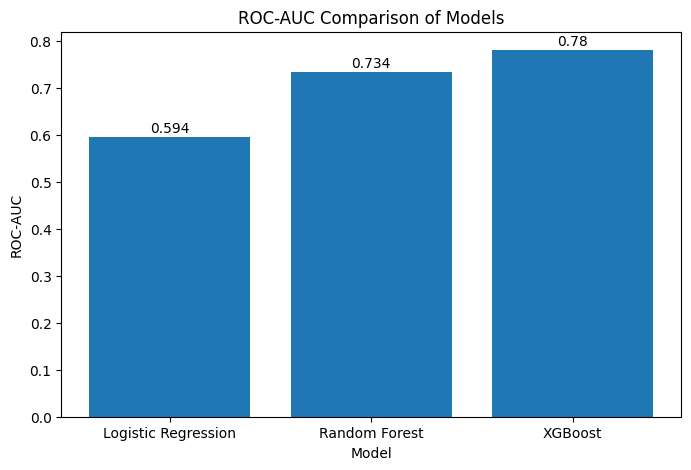

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['ROC_AUC']
)

plt.title("ROC-AUC Comparison of Models")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")

for i, v in enumerate(results_df['ROC_AUC']):
    plt.text(i, v+0.01, str(round(v,3)), ha='center')

plt.show()

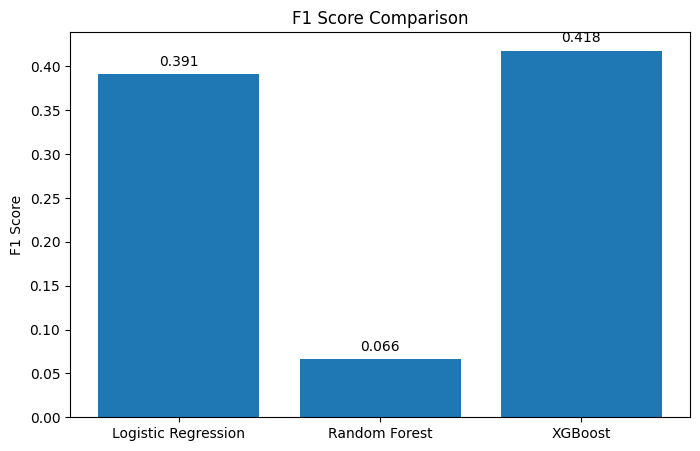

In [79]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['F1']
)

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")

for i, v in enumerate(results_df['F1']):
    plt.text(i, v+0.01, str(round(v,3)), ha='center')

plt.show()

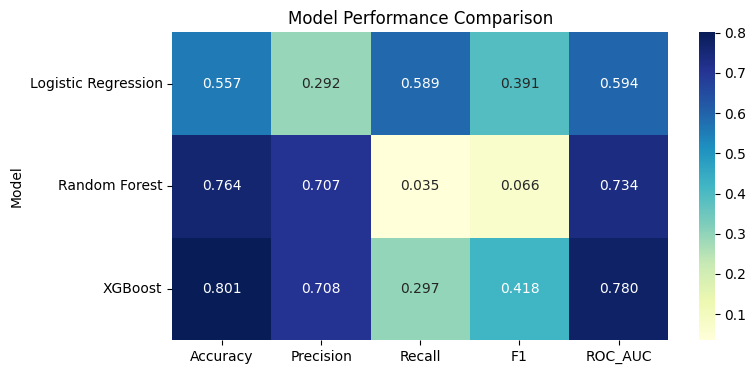

In [80]:
import seaborn as sns

plt.figure(figsize=(8,4))

sns.heatmap(
    results_df.set_index('Model'),
    annot=True,
    cmap='YlGnBu',
    fmt='.3f'
)

plt.title("Model Performance Comparison")

plt.show()

## Key Findings

1. Airline choice influences delay probability.
2. Certain states show consistently higher delays.
3. Departure hour strongly impacts delays.
4. Historical route performance improves prediction quality.
5. Evening flights are more delay-prone.

## Limitations

1. Dataset contains only January 2024 flights.

2. Weather information is unavailable.

3. Real-time operational factors are not included.

## Future Scope

1. Weather integration.

2. Real-time flight APIs.

3. Dynamic recovery recommendations.

4. Airport congestion forecasting.

## Conclusion



This project developed a Flight Delay Prediction and Recovery System using machine learning techniques on over 558,000 flight records. Extensive data preprocessing, exploratory data analysis, and feature engineering were performed to identify the major factors influencing flight delays.

Three machine learning models were evaluated: Logistic Regression, Random Forest, and XGBoost. Among them, XGBoost achieved the best overall performance and was selected as the final model for deployment.

The analysis revealed that airline operations, airport location, departure timing, and route characteristics significantly influence flight delays. The developed system can assist airlines and airport operators in proactively identifying high-risk flights and taking preventive actions.

Future enhancements include integration of weather data, real-time flight information, airport congestion metrics, and advanced operational recovery recommendations.
